In [1]:
from __future__ import annotations

import importlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LogNorm

pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option('display.max_rows', 500)


config_dir = Path.home() / '.pulsepoint'
sys.path.insert(0, str(config_dir))

from dotenv import load_dotenv

load_dotenv(config_dir / '.env', override=False)
from dbfuncs import query2df

# Email -> NPI density per source (pii_clean)

**Goal:** find thresholds to clean bad-quality emails, i.e. emails that map to several unrelated people.
**Idea:** for each email, count how many distinct NPIs it has. A good email has 1. The more NPIs, the more likely it is shared or wrong.
We measure this per source to see which sources are dirty and where to cut.


## 1. Base query and density per source

In [2]:
# Base query (same idea as the sample query above, but on the FULL day, no sampling).
# One row per (source, email) with the number of distinct NPIs / first names / last names.
# Blank names are ignored when counting names.
# Every query below re-uses this one.
#
# Filters taken from the original reference query:
#   - valid email format, valid 10-digit NPI
#   - fake test data: names/emails starting with 'fuck', emails 'testqaa@%', NPIs '1234%', '2222222222', '1010101010'
#   - name check against the NPI registry: drop rows where the name does NOT match the NPI owner ('not match').
#     'match' and 'not found' are kept. Rows with a blank name are kept too (nothing to compare).
day = '2026-09-28'

cte_emails = f"""
        select p.source, p.emails, p.npi, p.first_name, p.last_name, n.first_name as npir_first_name, n.last_name as npir_last_name,
            case when 
                    lower(p.first_name) = lower(n.first_name) 
                    and lower(p.last_name) = lower(n.last_name) 
                    then 'match'
                 when 
                    n.first_name is null 
                    and n.last_name is null 
                    then 'not found'
                 else 'not match' end as name_check
        from iceberg.thirdparty.pii_clean as p
        left join iceberg.npi.npi_reference as n on p.npi = n.npi
        where p.day = '{day}'
          and p.emails like '%_@__%.__%'
          and not (p.emails like 'domains@%__.__%')
          and p.npi is not null and length(p.npi) = 10
          and lower(p.first_name) not like 'fuck%'
          and lower(p.emails) not like 'fuck%'
          and lower(p.emails) not like 'testqaa@%'
          and p.npi not like '1234%'
          and p.npi not in ('2222222222', '1010101010')
          --and p.source <> 'ENDATO' 
"""
agg_sql = f"""
    with cte_emails as ({cte_emails})
    select source, emails,
        count(distinct npi) as nd_npi,
        count(distinct case when trim(first_name) <> '' then lower(trim(first_name)) end) as nd_fname,
        count(distinct case when trim(last_name) <> '' then lower(trim(last_name)) end) as nd_lname
    from cte_emails
    where name_check <> 'not match'
        or trim(coalesce(first_name, '')) = '' or trim(coalesce(last_name, '')) = ''
    group by source, emails
"""

In [5]:
density = query2df(f"""
    with agg as ({agg_sql})
    select source,
        count(*) as n_emails,
        count_if(nd_npi = 1) as n_1_npi,
        count_if(nd_npi = 2) as n_2_npi,
        count_if(nd_npi between 3 and 5) as n_3_to_5_npi,
        count_if(nd_npi > 5) as n_6plus_npi,
        max(nd_npi) as max_npi
    from agg
    group by source
    order by source
""")

# turn counts into percentages
density['pct_2_npi'] = density['n_2_npi'] / density['n_emails'] * 100
density['pct_3plus_npi'] = (density['n_3_to_5_npi'] + density['n_6plus_npi']) / density['n_emails'] * 100
density

Query executed in 12.945 seconds


,source,n_emails,n_1_npi,n_2_npi,n_3_to_5_npi,n_6plus_npi,max_npi,pct_2_npi,pct_3plus_npi
0,drdb,757978,751702,6265,11,0,3,0.827,0.001
1,endato,5064100,4981143,80508,2275,174,2077,1.590,0.048
2,haymarket,3633925,3633925,0,0,0,1,0.000,0.000
3,medscape,2583236,2537477,45753,6,0,3,1.771,0.000
4,rocketreach,2917580,2891083,23622,2592,283,21,0.810,0.099
5,stdvendor,11764905,11691233,73638,30,4,16,0.626,0.000


## 2. How to read the table and chart

- Most emails have **1 NPI** (normal). `pct_2_npi` / `pct_3plus_npi` = share of emails with 2 / 3+ NPIs.
- **3+ NPIs** is tiny in every source (<0.1%) but is where the junk lives (`max_npi` shows emails with up to ~2,000 NPIs).
- **2 NPIs** is big in some sources (endato ~1.6%, medscape ~1.8%), but 2 NPIs can also be the same person with a duplicate NPI. So we cannot cut at 2 NPIs blindly (see section 4).
- haymarket is always 1 NPI per email.
- The name check against the NPI registry (see the base query) already removed rows whose name does not match the NPI owner: 13-20% of rows in drdb, endato, haymarket, medscape, rocketreach and stdvendor (some of those are blank names, which are kept). The `|` split, `fuck%` and `testqaa@` filters change nothing in `pii_clean` (no such rows).

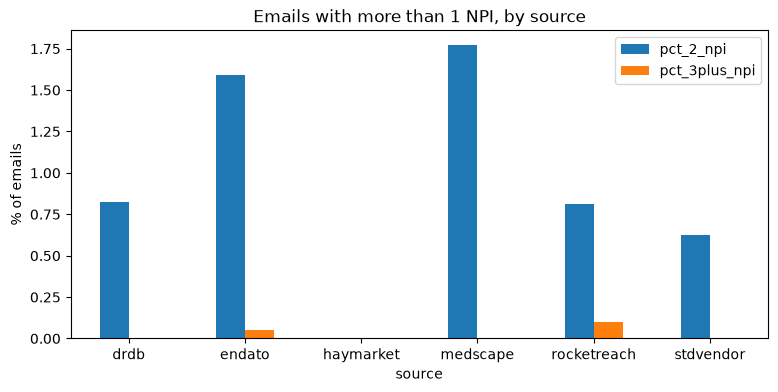

In [6]:
# Chart: % of emails with 2 NPIs and with 3+ NPIs, per source
ax = density.set_index('source')[['pct_2_npi', 'pct_3plus_npi']].plot(kind='bar', figsize=(9, 4))
ax.set_ylabel('% of emails')
ax.set_title('Emails with more than 1 NPI, by source')
plt.xticks(rotation=0)
plt.show()

## 3. Worst emails (10+ NPIs)

These are clearly not one person: shared mailboxes, hosting / billing / privacy addresses, free-mail accounts reused many times.
Any threshold of 3+ NPIs removes them all.

In [7]:
# The 15 emails with the most NPIs (eyeball: are they shared / generic inboxes?)
query2df(f"""
    with agg as ({agg_sql})
    select source, emails, nd_npi
    from agg
    where nd_npi >= 10
    order by nd_npi desc
    limit 15
""")

Query executed in 12.793 seconds


,source,emails,nd_npi
0,endato,jjanik@msn.com,2077
1,endato,pfreddielee@yahoo.com,643
2,endato,hosting@att-webhosting.com,330
3,endato,anaid@msn.com,327
4,endato,rachellefagan@hotmail.com,279
5,endato,aryoung7@bellsouth.net,273
6,endato,mikey.flores@yahoo.com,271
7,endato,darkminde@hotmail.com,270
8,endato,kaitlinhynes@yahoo.com,205
9,endato,alaboyd@hotmail.com,178


## 4. Emails with exactly 2 NPIs: same person or different people?

2 NPIs can be one person with a duplicate NPI (fine) or two different people sharing an email (bad).
We tell them apart by looking at the names on the email:
- `same_name`: one first name and one last name -> same person, keep.
- `different_names`: more than one name -> different people, bad.
- `no_name`: names are empty, cannot tell.

Reading: **medscape and stdvendor** are almost all the same person (<0.5% different). **endato (97%)** is almost all different people. **rocketreach (68%)** is mostly different people. **drdb (27%)** is mixed.

In [8]:
# For emails with exactly 2 NPIs: are the names the same or different?
two_npi = query2df(f"""
    with agg as ({agg_sql})
    select source,
        count(*) as n_emails_2npi,
        count_if(nd_lname = 0) as no_name,
        count_if(nd_lname = 1 and nd_fname <= 1) as same_name,
        count_if(nd_lname > 1 or nd_fname > 1) as different_names
    from agg
    where nd_npi = 2
    group by source
    order by source
""")
two_npi['pct_different_names'] = two_npi['different_names'] / two_npi['n_emails_2npi'] * 100
two_npi

Query executed in 21.185 seconds


,source,n_emails_2npi,no_name,same_name,different_names,pct_different_names
0,drdb,6265,2,4572,1691,26.991
1,endato,80508,0,2638,77870,96.723
2,medscape,45753,0,45547,206,0.450
3,rocketreach,23622,30,7538,16054,67.962
4,stdvendor,73638,28,73368,242,0.329


## 5. Apply the rule: how many emails would we remove per source?

Rule: **bad email = 3 or more NPIs, or exactly 2 NPIs with different names.**
`pct_bad` is the share of the source's emails that would be cleaned out.

In [9]:
# Apply the rule: bad = 3+ NPIs, or 2 NPIs with different names
bad = query2df(f"""
    with agg as ({agg_sql})
    select source,
        count(*) as n_emails,
        count_if(nd_npi >= 3) as bad_3plus,
        count_if(nd_npi = 2 and (nd_fname > 1 or nd_lname > 1)) as bad_2npi_diff_names
    from agg
    group by source
    order by source
""")
bad['bad_total'] = bad['bad_3plus'] + bad['bad_2npi_diff_names']
bad['pct_bad'] = bad['bad_total'] / bad['n_emails'] * 100
bad

Query executed in 17.840 seconds


,source,n_emails,bad_3plus,bad_2npi_diff_names,bad_total,pct_bad
0,drdb,757978,11,1691,1702,0.225
1,endato,5064100,2449,77870,80319,1.586
2,haymarket,3633925,0,0,0,0.000
3,medscape,2583236,6,206,212,0.008
4,rocketreach,2917580,2875,16054,18929,0.649
5,stdvendor,11764905,34,242,276,0.002


## 6. Conclusion (day 2026-09-28)

- **Rule to clean emails:** drop an email if it has **3 or more NPIs**, or has **2 NPIs with different names**. Keep 2 NPIs with the same name (same person, duplicate NPI).
- This comes **on top of** the NPI registry name check (rows whose name does not match the NPI owner are already removed in the base query).
- **haymarket**: clean, 1 NPI per email always.
- **medscape / stdvendor**: almost all 2-NPI emails are the same person. Very little to remove (~0.008% / ~0.002%).
- **endato (~1.6%), rocketreach (~0.65%), drdb (~0.2%)**: these sources need the cleaning. endato and rocketreach 2-NPI emails are mostly different people. drdb is smaller once the name check is applied.
- **Stability:** repeated on 2026-09-28 to 2026-10-06 (section 7). The bad-email counts are the same every day (medscape moves from 212 to 214), so the thresholds can be fixed.

## 7. Impact: impressions and revenue on cookies linked to bad emails (2026-09-28 to 2026-10-06)

**Question:** if the bad emails (rule from section 5) are removed, how many impressions and how much revenue do we lose in `vault.mpcdatavault` with `deflevelid = 8`?

**How:** bad email -> sha256 -> `liveintent_idsync` (email -> cookie) -> `mpcdatavault.visitorguid`. Impressions are then split by whether the `matchid` they were served with can be found in `nscreen_lr_throtle_ex_reason_result` (cs).

**Windows:** 9 days, from 2026-09-28 to 2026-10-06. Each day is measured on its own date for every source (`pii_clean`, `liveintent_idsync`, `mpcdatavault`, cs), so the email -> cookie link and the impression are from the same moment.
- cs is **never widened across days**. `matchid` drifts: over 6 days only 11.1M of ~17M cookies kept a single `matchid` (the rest had 2 to 9), so a wider window fans out and attaches impressions to the wrong cluster.

**Join keys:**
- `servedgraphid` is the `matchid` the impression was served with. It comes as `NS_S_<id>`, `NSH_S_<id>`, `NS_<id>` or empty; cs `matchid` is `S_<id>`. We strip `^NSH?_` first. Joining without this returns 0 rows.
- 43% to 47% of deflevel-8 impressions have an empty `servedgraphid`. They cannot join on `matchid`, only on the cookie id, and cleaning emails does not change them.
- `servedgraphid` is the `matchid` at serve time and cs `matchid` is the one of that day, so they can differ for the same cookie (`graph_matchid_differs`).

**Reading the result:**
- `with matchid` = non-empty `servedgraphid`. This is the traffic that cleaning emails can change. The `graph_group` column in the table uses the same split: `empty_graph` (no matchid), `graph_uid_not_in_cs`, `graph_matchid_equal`, `graph_matchid_differs`.
- `only_bad`: the cookie has bad emails and no good email -> real loss if bad emails are dropped.
- `mixed`: the cookie also has a good email -> upper bound only.
- `cookie-day`: one cookie on one day. The same cookie seen on three days counts three times.
- Source table (`n_bad_emails` by source): one row per email source, plus an `ANY` row. A cookie-day with bad emails from two sources appears in both source rows, so the source rows must not be added up. `ANY` counts each cookie-day once, whichever sources the bad emails came from, and its `n_bad_emails` counts bad emails across all sources. The headline totals come from `ANY`.


In [1]:
from concurrent.futures import ThreadPoolExecutor
from datetime import date, timedelta

from dbfuncs import query2table, table_exists

# Windows: each day is measured on its own date, for every source.
# cs is NOT widened across days: matchid drifts (only ~66% of cookies keep one matchid over 6 days).
START_DAY, END_DAY = '2026-09-28', '2026-10-06'
DAYS = [
    (date.fromisoformat(START_DAY) + timedelta(days=i)).isoformat()
    for i in range((date.fromisoformat(END_DAY) - date.fromisoformat(START_DAY)).days + 1)
]
exposure_schema = 'iceberg.jteixeira_ipa'
exposure_table = 'tmp_mpc_deflevel8_bad_email_exposure_20260928_20261006'
exposure = f"{exposure_schema}.{exposure_table}"
REBUILD_EXPOSURE = False  # each day takes ~4 min; days already in the table are skipped
SOURCES = ['drdb', 'endato', 'medscape', 'rocketreach', 'stdvendor']

# Same bad-email rule as section 5.
bad_rule = "(nd_npi >= 3 or (nd_npi = 2 and (nd_fname > 1 or nd_lname > 1)))"
email_src_cols = ",\n        ".join(
    f"max(case when source = '{s}' and {bad_rule} then 1 else 0 end) as bad_{s}" for s in SOURCES
)
uid_src_cols = ",\n        ".join(f"sum(bad_{s}) as n_bad_{s}" for s in SOURCES)
final_src_cols = ",\n    ".join(f"coalesce(a.n_bad_{s}, 0) as n_bad_{s}" for s in SOURCES)


def agg_sql_for_day(d: str) -> str:
    # Section 1 query, pointed at another pii_clean day.
    sql = agg_sql.replace(f"p.day = '{day}'", f"p.day = '{d}'")
    assert f"p.day = '{d}'" in sql
    return sql


def exposure_sql_for_day(d: str) -> str:
    return f"""
with agg as ({agg_sql_for_day(d)}),
-- one row per email hash; bad if bad in any source
emails as (
    select lower(to_hex(sha256(to_utf8(lower(trim(emails)))))) as hashedemail,
        max(case when {bad_rule} then 1 else 0 end) as is_bad,
        {email_src_cols}
    from agg
    group by 1
),
-- deflevelid=8 impressions per (cookie, served graph). servedgraphid comes as NS_S_<id>, NSH_S_<id>, NS_<id> or empty.
mpc as (
    select visitorguid as uid,
        nullif(regexp_replace(servedgraphid, '^NSH?_', ''), '') as gid,
        sum(impressions) as imps,
        sum(revcpm * impressions / 1000.0 + revcpc * clicks) as rev
    from vault.mpcdatavault
    where day = '{d}' and deflevelid = 8
    group by 1, 2
),
mpc_uids as (select distinct uid from mpc),
cs as (
    select c.uid, c.matchid
    from iceberg.crossscreen.nscreen_lr_throtle_ex_reason_result c
    join mpc_uids u on u.uid = c.uid
    where c.day = '{d}'
    group by 1, 2
),
mpc_flag as (
    select m.uid, m.gid, m.imps, m.rev,
        count(cs.uid) as n_cs,
        max(case when cs.matchid = m.gid then 1 else 0 end) as hit
    from mpc m
    left join cs on cs.uid = m.uid
    group by 1, 2, 3, 4
),
-- email -> cookie through the LiveIntent id sync
uid_emails as (
    select distinct split_part(t.tok, ':', 2) as uid, e.*
    from iceberg.thirdparty.liveintent_idsync s
    join emails e on lower(s.hashedemail_sha256) = e.hashedemail
    cross join unnest(split(s.uids, '|')) as t(tok)
    join mpc_uids u on u.uid = split_part(t.tok, ':', 2)
    where s.day = '{d}' and t.tok <> ''
),
uid_agg as (
    select uid,
        sum(is_bad) as n_bad,
        count(*) - sum(is_bad) as n_good,
        {uid_src_cols}
    from uid_emails
    group by uid
)
select '{d}' as day,
    m.uid,
    case when m.gid is null then 'empty_graph'
         when m.n_cs = 0 then 'graph_uid_not_in_cs'
         when m.hit = 1 then 'graph_matchid_equal'
         else 'graph_matchid_differs' end as graph_group,
    m.imps, m.rev,
    coalesce(a.n_bad, 0) as n_bad,
    coalesce(a.n_good, 0) as n_good,
    {final_src_cols}
from mpc_flag m
left join uid_agg a on a.uid = m.uid
"""


def load_day(d: str, create: bool) -> str:
    query2table(
        exposure_sql_for_day(d), exposure_table, catalog_schema=exposure_schema,
        insert=not create, recreate=create, sort_keys=['uid'] if create else None,
        print_time=False,
    )
    return d


done_days = set()
if table_exists(exposure_table, catalog_schema=exposure_schema) and not REBUILD_EXPOSURE:
    done_days = set(query2df(f"select distinct day from {exposure}")['day'])

todo = [d for d in DAYS if d not in done_days]
if todo:
    if not done_days:
        load_day(todo[0], create=True)  # first day creates the table
        todo = todo[1:]
    with ThreadPoolExecutor(max_workers=3) as pool:  # remaining days load 3 at a time
        list(pool.map(lambda d: load_day(d, create=False), todo))

query2df(f"select day, count(*) as rows_, sum(imps) as impressions, sum(rev) as revenue from {exposure} group by 1 order by 1")


          day     rows_  impressions       revenue
0  2026-09-28  27010795    112951952  1.680263e+06
1  2026-09-29  27359858    114882075  1.755689e+06
2  2026-09-30  25886034    105219775  1.644975e+06
3  2026-10-01  23743780     94125713  1.402081e+06
4  2026-10-02  24196997     99491696  1.421112e+06
5  2026-10-03  23828254     98740483  1.382762e+06
6  2026-10-04  24785673    101347580  1.454609e+06
7  2026-10-05  24632306    100142697  1.468069e+06
8  2026-10-06  23795520     96766251  1.445741e+06

In [2]:
# Day by day: how much traffic sits on cookies linked to a bad email.
# "with matchid" = non-empty servedgraphid, the only traffic that cleaning emails can change.
daily = query2df(f"""
    select day,
        sum(imps) as imps_total,
        sum(rev) as rev_total,
        sum(case when graph_group <> 'empty_graph' then imps end) as imps_graph,
        sum(case when graph_group <> 'empty_graph' then rev end) as rev_graph,
        sum(case when graph_group <> 'empty_graph' and n_bad > 0 then imps else 0 end) as imps_bad_graph,
        sum(case when graph_group <> 'empty_graph' and n_bad > 0 then rev else 0 end) as rev_bad_graph,
        sum(case when n_bad > 0 then imps else 0 end) as imps_bad_all,
        sum(case when n_bad > 0 then rev else 0 end) as rev_bad_all,
        count(distinct case when n_bad > 0 then uid end) as cookies_bad
    from {exposure}
    group by 1
    order by 1
""")
daily['pct_imps_bad_graph'] = daily['imps_bad_graph'] / daily['imps_graph'] * 100
daily['pct_rev_bad_graph'] = daily['rev_bad_graph'] / daily['rev_graph'] * 100
daily['pct_rev_bad_all'] = daily['rev_bad_all'] / daily['rev_total'] * 100
daily


          day  imps_total     rev_total  imps_graph     rev_graph  imps_bad_graph  rev_bad_graph  imps_bad_all  rev_bad_all  cookies_bad  pct_imps_bad_graph  pct_rev_bad_graph  pct_rev_bad_all
0  2026-09-28   112951952  1.680263e+06    64229845  9.642615e+05            7082      96.463586         19857   297.764251         2505            0.011026           0.010004         0.017721
1  2026-09-29   114882075  1.755689e+06    65845190  1.024425e+06            7230      93.128639         19042   273.497990         2520            0.010980           0.009091         0.015578
2  2026-09-30   105219775  1.644975e+06    60693104  9.809055e+05            6018      91.918732         16521   252.571880         2448            0.009915           0.009371         0.015354
3  2026-10-01    94125713  1.402081e+06    51469983  8.084185e+05            5205      76.928224         15831   247.886854         2251            0.010113           0.009516         0.017680
4  2026-10-02    99491696  1.421112

In [3]:
# Stability of the bad-email set itself: section 5 rule applied to every day.
bad_by_day = pd.concat(
    [
        query2df(f"""
            with agg as ({agg_sql_for_day(d)})
            select '{d}' as day, source,
                count(*) as n_emails,
                count_if(nd_npi >= 3 or (nd_npi = 2 and (nd_fname > 1 or nd_lname > 1))) as bad_total
            from agg
            group by source
        """, print_time=False)
        for d in DAYS
    ],
    ignore_index=True,
)
bad_by_day['pct_bad'] = bad_by_day['bad_total'] / bad_by_day['n_emails'] * 100
bad_by_day.pivot(index='day', columns='source', values='bad_total')


source      drdb  endato  haymarket  medscape  rocketreach  stdvendor
day                                                                  
2026-09-28  1702   80319          0       212        18929        276
2026-09-29  1702   80319          0       212        18929        276
2026-09-30  1702   80319          0       212        18929        276
2026-10-01  1702   80319          0       213        18929        276
2026-10-02  1702   80319          0       213        18929        276
2026-10-03  1702   80319          0       213        18929        276
2026-10-04  1702   80319          0       213        18929        276
2026-10-05  1702   80319          0       214        18929        276
2026-10-06  1702   80319          0       214        18929        276

In [4]:
# Whole period: for each graph_group (how the served matchid compares to cs), how much traffic sits on cookies linked to bad emails.
# only_bad = cookie has bad emails and no good one -> real loss if bad emails are dropped.
# mixed    = cookie also keeps a good email -> upper bound only.
summary = query2df(f"""
    select graph_group,
        case when n_bad + n_good = 0 then '0_no_email_link'
             when n_bad = 0 then '1_good_only'
             when n_good > 0 then '2_mixed_bad_and_good'
             else '3_only_bad' end as email_class,
        count(*) as cookie_days,
        sum(imps) as impressions,
        sum(rev) as revenue
    from {exposure}
    group by 1, 2
    order by 1, 2
""")
tot = summary.groupby('graph_group')[['impressions', 'revenue']].transform('sum')
summary['pct_imps_of_group'] = summary['impressions'] / tot['impressions'] * 100
summary['pct_rev_of_group'] = summary['revenue'] / tot['revenue'] * 100
summary


              graph_group           email_class  cookie_days  impressions       revenue  pct_imps_of_group  pct_rev_of_group
0             empty_graph       0_no_email_link    103261133    397386849  5.568055e+06          96.334990         96.258424
1             empty_graph           1_good_only      2102092     15016179  2.147903e+05           3.640240          3.713214
2             empty_graph  2_mixed_bad_and_good         1204         6935  1.594353e+02           0.001681          0.002756
3             empty_graph            3_only_bad        14230        95241  1.481155e+03           0.023088          0.025606
4   graph_matchid_differs       0_no_email_link     36684441    130603615  2.001404e+06          98.573345         98.572176
5   graph_matchid_differs           1_good_only       508367      1875773  2.877275e+04           1.415744          1.417101
6   graph_matchid_differs  2_mixed_bad_and_good          152          473  1.268880e+01           0.000357          0.000625


In [5]:
# Requested shape: bad-email source x number of bad emails on the cookie, summed over the whole period.
# A cookie-day with bad emails from 2 sources shows up in both source rows; 'ANY' is the de-duplicated total.
def exposure_by_source(graph_filter: str) -> pd.DataFrame:
    parts = [
        f"""select '{s}' as source,
                case when n_bad_{s} >= 6 then '6+' else cast(n_bad_{s} as varchar) end as n_bad_emails,
                uid, imps, rev, n_good
            from {exposure} where n_bad_{s} > 0 and {graph_filter}"""
        for s in SOURCES
    ]
    parts.append(f"""select 'ANY' as source,
                case when n_bad >= 6 then '6+' else cast(n_bad as varchar) end as n_bad_emails,
                uid, imps, rev, n_good
            from {exposure} where n_bad > 0 and {graph_filter}""")
    return query2df(f"""
        select source, n_bad_emails,
            count(*) as cookie_days,
            sum(imps) as impressions,
            sum(rev) as revenue,
            sum(case when n_good = 0 then imps else 0 end) as impressions_only_bad,
            sum(case when n_good = 0 then rev else 0 end) as revenue_only_bad
        from ({' union all '.join(parts)})
        group by 1, 2
        order by 1, 2
    """)

# Impressions with a matchid only (servedgraphid not empty): this is what cleaning emails could change.
loss_graph = exposure_by_source("graph_group <> 'empty_graph'")
loss_graph


        source n_bad_emails  cookie_days  impressions     revenue  impressions_only_bad  revenue_only_bad
0          ANY            1        10325        54948  787.737440                 53129        755.204374
1          ANY            2           39          124    1.316547                   123          1.314518
2         drdb            1          256         1288   12.357809                  1274         11.977909
3       endato            1         9218        50173  714.706719                 48576        687.150516
4       endato            2           39          124    1.316547                   123          1.314518
5     medscape            1           30           68    1.159230                    68          1.159230
6  rocketreach            1          850         3539   60.906578                  3331         56.309614
7    stdvendor            1            1            4    0.116475                     4          0.116475

### Result (9 days, 2026-09-28 to 2026-10-06)

Period totals, deflevel 8: 923.7M impressions and $13.66M revenue. With a matchid (non-empty `servedgraphid`): 511.2M impressions and $7.87M.

| | Impressions | Revenue | Share |
|---|---|---|---|
| Impressions with a matchid on cookies linked to a bad email | 55,072 | $789 | 0.011% of impressions, 0.010% of revenue |
| Same, including impressions with no matchid | 157,248 | $2,430 | 0.017% of impressions, 0.018% of revenue |

- **Loss is negligible and stable.** Per day, impressions with a matchid on bad-email cookies stay between 5.2K and 7.2K (0.010% to 0.011%), and revenue between $77 and $96 (0.009% to 0.011%). No day stands out.
- **Run rate:** about $88 a day, or roughly **$2.6K a month** for impressions with a matchid. About $270 a day, or $8.1K a month, if impressions with no matchid are included.
- **Almost all of it is real loss.** 97% of the exposure on impressions with a matchid is `only_bad` (the cookie has no good email to fall back on); `mixed` is only 1,820 impressions over the 9 days.
- **Cookies carry one bad email.** 10,325 cookie-days with 1 bad email, 39 with 2, none with 3+. Between 2,200 and 2,500 cookies a day are affected.
- **Source:** endato is ~89% of the exposure, then rocketreach (850 cookie-days), drdb (256), medscape (30), stdvendor (1).
- **The bad-email set does not move.** The section 5 rule gives the same counts every day for drdb, endato, rocketreach and stdvendor (1,702 / 80,319 / 18,929 / 276), haymarket stays at 0, and medscape moves from 212 to 214. `pii_clean` barely changes day to day, so this is a stable list.
- **Caveat:** only about 1.5% of deflevel-8 cookie/matchid pairs link to any `pii_clean` email through the id sync, so this measures only the HCP-email slice of the traffic. Emails that fail the base filters (invalid format, bad NPI, test data) are not in the bad set and are not counted here.
